[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/usutradhar/quantify-infrastructure/blob/main/Random_effect_RBUV.ipynb)

In [ ]:
# import all packages
import sys
from io import StringIO
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

import geopandas as gpd
import time

pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
##################################################################################################

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = "/content/drive/MyDrive/quantify-infrastructure-code"

### Load historical data

In [ ]:
county_pop_2005 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/co-est00int-tot.csv", header=0,encoding='latin1')
county_pop_2005[county_pop_2005['COUNTY'] !=0][['STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'POPESTIMATE2005']]
county_pop_2005['state_code'] = county_pop_2005['STATE'].astype(str).str.rjust(2, '0')
county_pop_2005['county_code'] = county_pop_2005['COUNTY'].astype(str).str.rjust(3, '0')
county_pop_2005['county_code'] = county_pop_2005['state_code'] + county_pop_2005['county_code']

county_2_place_code = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/County_to_Place_Population_2005.csv", header=1)
county_2_place_code[['FIPS state', 'placefp', 'Place Name', 'Total Pop, 2000 census']]
county_2_place_code['state_code'] = county_2_place_code['FIPS state'].astype(str).str.rjust(2, '0')
county_2_place_code['county_code'] = county_2_place_code['county'].astype(str).str.rjust(5, '0')
county_2_place_code['place_code'] = county_2_place_code['placefp'].astype(str).str.rjust(5, '0')
county_2_place_code['GEOID'] = county_2_place_code['state_code'] + county_2_place_code['place_code']
county_2_place_df = county_2_place_code[['county_code', 'GEOID', 'Place Name','county to placefp allocation factor']]

df_pop_2005 = county_2_place_df.merge(county_pop_2005[['county_code', 'POPESTIMATE2005']], on ='county_code')
df_pop_2005['Est_Pop_2005'] = df_pop_2005['county to placefp allocation factor'] * df_pop_2005['POPESTIMATE2005']
df_pop_2005 = df_pop_2005[df_pop_2005['Place Name'] != ' '][['GEOID', 'Place Name','Est_Pop_2005']]
df_pop_2005.columns = ['GEOID', 'NAME', 'Est_Pop_2005']
df_pop_2005['GEOID'] = df_pop_2005['GEOID'].str[-7:]
# Places can be in multiple counties, so summarize by GEOID. NAME
df_pop_2005 = df_pop_2005.groupby(['GEOID', 'NAME'])['Est_Pop_2005'].sum().reset_index()

In [ ]:
df_pop_2015 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/ACSDP5Y2015.DP05-Data.csv", header=1)
df_pop_2015 = df_pop_2015[['Geography', 'Geographic Area Name', 'Estimate!!SEX AND AGE!!Total population']]
df_pop_2015.columns = ['GEOID', 'NAME', 'ACS_Pop_2015']
df_pop_2015['GEOID'] = df_pop_2015['GEOID'].str[-7:]

df_pop_2010 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/DECENNIALPL2010.P1-Data.csv", header=1)
df_pop_2010 = df_pop_2010[['Geography', 'Geographic Area Name', 'Total']]
df_pop_2010.columns = ['GEOID', 'NAME', 'CensusPop_2010']
df_pop_2010['GEOID'] = df_pop_2010['GEOID'].str[-7:]

df_pop_2000 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/DECENNIALDPSF22000.DP1-Data.csv", header=1)
df_pop_2000 = df_pop_2000[['Geography', 'Geographic Area Name', 'Number!!Total population']]
df_pop_2000.columns = ['GEOID', 'NAME', 'CensusPop_2000']
df_pop_2000['GEOID'] = df_pop_2000['GEOID'].str[-7:]


df_2020 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Volume/BuiltArea_GHSL_V_2020.csv")
df_2020['GEOID'] = df_2020['GEOID'].astype(str).str.rjust(7,'0')
df_2020 = df_2020[['GEOID','sum']]
df_2020.columns = ['GEOID', 'volume_2020']

df_2015 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Volume/BuiltArea_GHSL_V_2015.csv")
df_2015['GEOID'] = df_2015['GEOID'].astype(str).str.rjust(7,'0')
df_2015 = df_2015[['GEOID','sum']]
df_2015.columns = ['GEOID', 'volume_2015']

df_2010 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Volume/BuiltArea_GHSL_V_2010.csv")
df_2010['GEOID'] = df_2010['GEOID'].astype(str).str.rjust(7,'0')
df_2010 = df_2010[['GEOID','sum']]
df_2010.columns = ['GEOID', 'volume_2010']

df_2005 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Volume/BuiltArea_GHSL_V_2005.csv")
df_2005['GEOID'] = df_2005['GEOID'].astype(str).str.rjust(7,'0')
df_2005 = df_2005[['GEOID','sum']]
df_2005.columns = ['GEOID', 'volume_2005']

df_2000 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Volume/BuiltArea_GHSL_V_2000.csv")
df_2000['GEOID'] = df_2000['GEOID'].astype(str).str.rjust(7,'0')
df_2000 = df_2000[['GEOID','sum']]
df_2000.columns = ['GEOID', 'volume_2000']

"""### Non residential buildings data from GHSL for the year 2020"""
df_non_res_2020 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/ghsl/Non_res_surface/BuiltArea_GHSL_V_nres_2020.csv")
df_non_res_2020['GEOID'] = df_non_res_2020['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_2020.rename(columns = {'sum':'volume_nonRes_2020'}, inplace= True)
df_non_res_2020.columns
df_non_res_2015 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/BuiltArea_GHSL_V_nres_2015.csv")
df_non_res_2015['GEOID'] = df_non_res_2015['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_2015.rename(columns = {'sum':'volume_nonRes_2015'}, inplace= True)
df_non_res_2015.columns
df_non_res_2010 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/BuiltArea_GHSL_V_nres_2010.csv")
df_non_res_2010['GEOID'] = df_non_res_2010['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_2010.rename(columns = {'sum':'volume_nonRes_2010'}, inplace= True)
df_non_res_2010.columns
df_non_res_2005 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/BuiltArea_GHSL_V_nres_2005.csv")
df_non_res_2005['GEOID'] = df_non_res_2005['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_2005.rename(columns = {'sum':'volume_nonRes_2005'}, inplace= True)
df_non_res_2005.columns
df_non_res_2000 = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/others/BuiltArea_GHSL_V_nres_2000.csv")
df_non_res_2000['GEOID'] = df_non_res_2000['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_2000.rename(columns = {'sum':'volume_nonRes_2000'}, inplace= True)
df_non_res_2000.columns


"""### Merge built are with nonResidential: Find residential only"""
# Merge surface with volume and non residential
# Here surface refers to total building are: res + non-res
df20 = df_2020.merge(df_non_res_2020[['GEOID', 'volume_nonRes_2020']], on ='GEOID')
df15 = df_2015.merge(df_non_res_2015[['GEOID', 'volume_nonRes_2015']], on ='GEOID')
df10 = df_2010.merge(df_non_res_2010[['GEOID', 'volume_nonRes_2010']], on ='GEOID')
df05 = df_2005.merge(df_non_res_2005[['GEOID', 'volume_nonRes_2005']], on ='GEOID')
df00 = df_2000.merge(df_non_res_2000[['GEOID', 'volume_nonRes_2000']], on ='GEOID')


df20['volume_Res_2020'] = df20['volume_2020'] - df20['volume_nonRes_2020']
df15['volume_Res_2015'] = df15['volume_2015'] - df15['volume_nonRes_2015']
df10['volume_Res_2010'] = df10['volume_2010'] - df10['volume_nonRes_2010']
df05['volume_Res_2005'] = df05['volume_2005'] - df05['volume_nonRes_2005']
df00['volume_Res_2000'] = df00['volume_2000'] - df00['volume_nonRes_2000']

print(df00.shape, df05.shape, df10.shape, df15.shape, df20.shape)
print(df_pop_2000.shape, df_pop_2005.shape, df_pop_2010.shape,df_pop_2015.shape)

df_buildings_only = df20.merge(df15.merge(df10.merge(df05.merge(df00, on = 'GEOID'), on ='GEOID'), on ='GEOID'), on ='GEOID')

df_prev_pop = df_pop_2015[['GEOID','ACS_Pop_2015']].merge(
    df_pop_2010[['GEOID', 'CensusPop_2010']].merge(
        df_pop_2005[['GEOID', 'Est_Pop_2005']].merge(
            df_pop_2000[["GEOID", 'CensusPop_2000']], on = 'GEOID'), on = 'GEOID',), on = 'GEOID')

df_buildings = df_buildings_only.merge(df_prev_pop, on = 'GEOID', how = 'outer')

(32188, 4) (32188, 4) (32188, 4) (32188, 4) (32188, 4)
(24047, 3) (25099, 3) (29514, 3) (29574, 3)


In [ ]:
df_buildings.isna().sum()

,0
GEOID,0
volume_2020,77
volume_nonRes_2020,77
volume_Res_2020,77
volume_2015,77
volume_nonRes_2015,77
volume_Res_2015,77
volume_2010,77
volume_nonRes_2010,77
volume_Res_2010,77


### Load 2020 data

In [ ]:
df_population = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/population/forecasted_trend.csv", index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/data/population/df_attributes.csv", index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi',
                                                'ua-to-place allocation factor_max', 'population_ua_min',
                                                'population_ua_max', 'median_income']], on = 'GEOID')

df_attributes.shape, df_population.shape

df_attributes.columns

df_population[(df_population['ssp42020'] -df_population['CensusPop_20']) > 0][['NAMELSAD', 'CensusPop_20','ssp22020', 'ssp22030', 'ssp22040',
                                                                            'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']]

df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070',
                'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090',
                'ssp42100']] =df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050',
                'ssp12060','ssp12070','ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060', 'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].round(0)

# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

"""### Merge buildings with population"""
print(df_buildings.shape, df_pop_attr.shape)

building_with_pop_all = df_buildings.merge(df_pop_attr[['GEOID', 'NAME', 'State', 'REGION', 'ua-to-place allocation factor_max', 'population_ua_min',
                                                    'population_ua_max','label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                                'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                                'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070',
                                                'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')

building_with_pop_all[building_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']]

building_with_pop_all.shape, df_buildings.shape, df_population.shape, df_attributes.shape

building_with_pop_all[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080','ssp22090','ssp22100',
                    'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100','ssp42020',
                    'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].isna().sum().sum()

building_with_pop_all['percentchangeinpop'] = np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20'])

print("Shape of building dataframe", building_with_pop_all.shape[0])

building_with_pop = building_with_pop_all[~building_with_pop_all['GEOID'].astype(str).str.startswith(('02', '60', '68', '69', '72', '78'))]
building_with_pop = building_with_pop[building_with_pop['ssp22020'].notnull()]
# building_with_pop.isna().sum()

Total population in millions for 51 states: ===
(32265, 20) (31616, 65)
Shape of building dataframe 32265


In [ ]:
df_buildings.shape, df_pop_attr.shape

((32265, 20), (31616, 65))

### Trying random effects by GEOID [individual city]

In [ ]:
city='urban'
df_city = building_with_pop[building_with_pop['city type'] == city].reset_index(drop=True)

df_RBUV_wide = df_city[['GEOID', 'NAME','REGION', 'volume_Res_2000', 'volume_Res_2005', 'volume_Res_2010',  'volume_Res_2015','volume_Res_2020']] #
RBUV_counts = df_RBUV_wide.groupby('GEOID').size().reset_index(name='count')
df_RBUV_wide = df_RBUV_wide.merge(RBUV_counts, on ='GEOID')
df_RBUV_wide = df_RBUV_wide[df_RBUV_wide['count']==1]

df_pop_wide = df_city[['GEOID', 'NAME', 'REGION', 'CensusPop_2000', 'Est_Pop_2005', 'CensusPop_2010', 'ACS_Pop_2015','CensusPop_20']] # ,'CensusPop_20'
pop_counts = df_pop_wide.groupby('GEOID').size().reset_index(name='count')
df_pop_wide = df_pop_wide.merge(pop_counts, on ='GEOID')
df_pop_wide = df_pop_wide[df_pop_wide['count']==1]


df_RBUV_long = pd.melt(
    df_RBUV_wide,
    id_vars=['GEOID', 'NAME', 'REGION'],              # Columns to keep as identifiers
    value_vars=['volume_Res_2000', 'volume_Res_2005', 'volume_Res_2010',  'volume_Res_2015','volume_Res_2020'],   # Columns to unpivot (optional, defaults to all others)
    var_name='vol_yr',               # Name for the new category column
    value_name='volume'                # Name for the new value column
)

df_pop_long = pd.melt(
    df_pop_wide,
    id_vars=['GEOID', 'NAME', 'REGION'],              # Columns to keep as identifiers
    value_vars=['CensusPop_2000', 'Est_Pop_2005', 'CensusPop_2010', 'ACS_Pop_2015','CensusPop_20'],   # Columns to unpivot (optional, defaults to all others)
    var_name='pop_yr',               # Name for the new category column
    value_name='population'                # Name for the new value column
)
# Check: dataframe shape and data types before merging
df_RBUV_long.shape, df_pop_long.shape, df_RBUV_long.dtypes, df_pop_long.dtypes

# Check: whether any city names appear more than once
count_v = df_RBUV_long.groupby('GEOID').size().reset_index(name='count')
count_p = df_pop_long.groupby('GEOID').size().reset_index(name='count')
print("Any cities presented more than once in the data")
count_v[count_v['count']!=5], count_p[count_p['count']!=5]

Any cities presented more than once in the data


(Empty DataFrame
 Columns: [GEOID, count]
 Index: [],
 Empty DataFrame
 Columns: [GEOID, count]
 Index: [])

In [ ]:
df =  pd.concat([df_RBUV_long, df_pop_long[['NAME', 'pop_yr', 'population']]], axis=1) #df_RBUV_long.merge(df_pop_long, on = ['GEOID'], )
df['year'] = df['vol_yr'].str[-4:].astype(int)
print(df.shape)

df["population"] = (
    df["population"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

print(f"Cleaned dataframe {df.shape}")

df = df[(df['population'] !=0) & (df['volume'] != 0)].reset_index(drop=True)
print(f"Excluding zero population / volume {df.shape}")

df_future = df[df['year']==2020].reset_index(drop=True)
print(df_future.isna().sum().sum())

df_historical = df[~df['year'].isin([2020])].reset_index(drop=True)

df_historical_naNA = df_historical.dropna()

df_historical_naNA_count = df_historical_naNA.groupby(['GEOID']).size().reset_index(name= 'count')

df_historical_clean = df_historical_naNA.merge(df_historical_naNA_count, on = 'GEOID')
df_model = df_historical_clean[df_historical_clean['count']==4]
df_model.drop('count', axis=1, inplace=True)
df_model.shape, df_future.shape, df.shape, df_historical.shape

(1560, 9)
Cleaned dataframe (1560, 9)
Excluding zero population / volume (1560, 9)
0


((1176, 9), (312, 9), (1560, 9), (1248, 9))

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Transform to log-log space for urban scaling
df_model["log_P"] = np.log(df_model["population"])
df_model["log_Y"] = np.log(df_model["volume"])

# --- 2. FIT THE MIXED EFFECTS SCALING MODEL ---
# 'log_P' is the global fixed effect (yields the universal exponent β)
# 'groups=df["city_id"]' estimates the unique structural error (α_i) for each city
model = smf.mixedlm("log_Y ~ log_P", data=df_model, groups=df_model["GEOID"])
results = model.fit()

print(results.summary())

# --- 3. EXTRACT THE PARAMETERS FOR VALIDATION & FORECASTS ---
beta_global = results.params["log_P"]
ln_Y0 = results.params["Intercept"]
city_structural_errors = results.random_effects # This is our α_i dictionary

print(f"\nGlobal Scaling Exponent (β): {beta_global:.4f}")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_Y    
No. Observations: 1176    Method:             REML     
No. Groups:       294     Scale:              0.0008   
Min. group size:  4       Log-Likelihood:     1150.6628
Max. group size:  4       Converged:          Yes      
Mean group size:  4.0                                  
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept   16.256    0.133 121.818 0.000 15.994 16.517
log_P        0.066    0.009   7.145 0.000  0.048  0.085
Group Var    2.411    8.508                            


Global Scaling Exponent (β): 0.0665


### Forecast

In [ ]:
# Extract random effects dictionary
random_effects = results.random_effects
# print("\n--- Extracted Random Intercept Shifts (u_j) by City Type ---")
# These are the unique structural offsets from the global baseline intercept
# for c_type, effect in random_effects.items():
#     print(f"City Type: {c_type:<20} | Random Intercept Offset: {effect['Group']:.4f}")

predictions = []

future_data = df_future[['GEOID','year','population', 'volume']]

future_data['log_population'] = np.log(future_data['population'])

# Extract fixed effects coefficients
alpha_0 = results.params['Intercept']
beta = results.params['log_P']

for idx, row in future_data.iterrows():
    c_type = row['GEOID']
    log_pop_future = row['log_population']

    # Step 1: Calculate Global Fixed Component
    fixed_prediction = alpha_0 + (beta * log_pop_future)

    # Step 2: Determine Random Effect Offset (u_i)
    if c_type in random_effects:
        # Known group: extract its specific calculated offset
        u_i = random_effects[c_type]['Group']
        # print(u_i)
        prediction_type = "Known Group (Fixed + Random Effect)"
    else:
        # Unknown/New group: default random effect to 0
        u_i = 0.0
        prediction_type = "New Group (Fixed Effect Only)"

    # Step 3: Combine and transform back from log space
    log_y_pred = fixed_prediction + u_i
    y_pred = np.exp(log_y_pred)

    predictions.append({
        'City Type': c_type,
        'Projected Pop': row['population'],
        'Random Effect Used (u_i)': round(u_i, 4),
        'Predicted Volume': round(y_pred, 2),
        'Method': prediction_type
    })

df_forecast = pd.DataFrame(predictions)
# print(df_forecast.to_string(index=False))

In [ ]:
df_F = df_future.merge(df_forecast, left_on='GEOID', right_on = 'City Type')
df_F['pct_diff'] = (df_F['Predicted Volume'] - df_F['volume'])*100/df_F['volume']

df_F[['GEOID', 'NAME','year', 'population','volume','Predicted Volume', "pct_diff"]].sort_values(by = 'pct_diff')
df_F[df_F['pct_diff']>0].shape, df_F[df_F['pct_diff']<0].shape, df_F[df_F['pct_diff']>30].shape, df_F[df_F['pct_diff']<-30].shape
# df_F[df_F['pct_diff']<-30][['GEOID', 'NAME','year', 'population','volume','Predicted Volume', "pct_diff", 'Random Effect Used (u_i)']]

((59, 15), (253, 15), (15, 15), (2, 15))

In [ ]:
df_F.groupby('Method')['pct_diff'].quantile([.05, .5, .95])

Method                                   
Known Group (Fixed + Random Effect)  0.05      -7.121537
                                     0.50      -1.338372
                                     0.95       0.373484
New Group (Fixed Effect Only)        0.05     -65.868464
                                     0.50     288.510889
                                     0.95    2423.401402
Name: pct_diff, dtype: float64

In [ ]:
df_F[df_F['Random Effect Used (u_i)']==0]#.sort_values(by = 'pct_diff')

,GEOID,NAME,REGION,vol_yr,volume,NAME,pop_yr,population,year,City Type,Projected Pop,Random Effect Used (u_i),Predicted Volume,Method,pct_diff
15,0616090,Contra Costa Centre,West,volume_Res_2020,3.783497e+06,Contra Costa Centre,CensusPop_20,6808.0,2020,0616090,6808.0,0.0,20639740.13,New Group (Fixed Effect Only),445.520182
66,0827950,Four Square Mile,West,volume_Res_2020,1.067985e+07,Four Square Mile,CensusPop_20,22872.0,2020,0827950,22872.0,0.0,22371475.32,New Group (Fixed Effect Only),109.473738
74,1200075,Acacia Villas,South,volume_Res_2020,4.261350e+05,Acacia Villas,CensusPop_20,398.0,2020,1200075,398.0,0.0,17089064.21,New Group (Fixed Effect Only),3910.246530
85,1228452,Hallandale Beach,South,volume_Res_2020,2.939211e+07,Hallandale Beach,CensusPop_20,41217.0,2020,1228452,41217.0,0.0,23264826.70,New Group (Fixed Effect Only),-20.846705
102,1243083,Marco Island,South,volume_Res_2020,5.755067e+07,Marco Island,CensusPop_20,15760.0,2020,1243083,15760.0,0.0,21824318.99,New Group (Fixed Effect Only),-62.078081
115,1269555,Sunny Isles Beach,South,volume_Res_2020,9.082246e+06,Sunny Isles Beach,CensusPop_20,22342.0,2020,1269555,22342.0,0.0,22336630.58,New Group (Fixed Effect Only),145.937313
118,1270345,Sweetwater,South,volume_Res_2020,9.994534e+06,Sweetwater,CensusPop_20,19363.0,2020,1270345,19363.0,0.0,22125118.99,New Group (Fixed Effect Only),121.372183
126,1571550,Urban Honolulu,West,volume_Res_2020,2.120122e+08,Urban Honolulu,CensusPop_20,350964.0,2020,1571550,350964.0,0.0,26825257.73,New Group (Fixed Effect Only),-87.347304
148,2430800,Friendship Heights Village,South,volume_Res_2020,8.984534e+05,Friendship Heights Village,CensusPop_20,5360.0,2020,2430800,5360.0,0.0,20314183.38,New Group (Fixed Effect Only),2161.016968
151,2446375,Leisure World,South,volume_Res_2020,5.377999e+06,Leisure World,CensusPop_20,9215.0,2020,2446375,9215.0,0.0,21059375.35,New Group (Fixed Effect Only),291.583834


In [ ]:
# df_ssp_forecast[df_ssp_forecast['u_i']!=0][['GEOID', 'volume_Res_2020', 'Predicted_Volume_2030', 'Predicted_Volume_2040','%diff']].sort_values(by = '%diff').head(30)

In [ ]:
df_plot = df_F[df_F['Random Effect Used (u_i)']!=0]

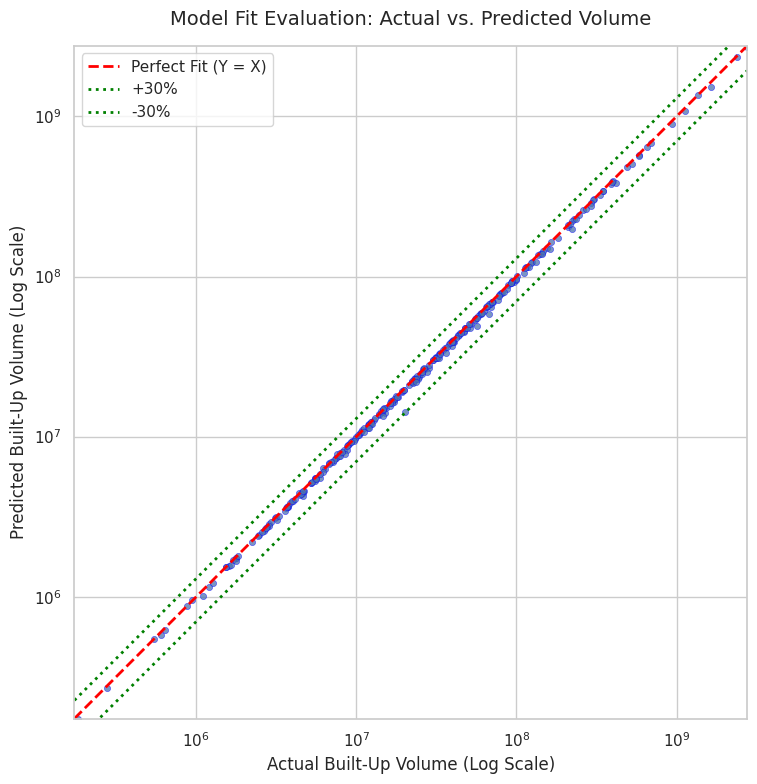

In [ ]:
# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 8))  # Square figure works best for Actual vs. Predicted

# Create the scatter plot
scatter = sns.scatterplot(
    data=df_plot,
    x='volume',               # Actual historical volume
    y='Predicted Volume',     # Model's forecast volume
    alpha=0.75,
    edgecolor='blue',
    s=20
)

# Set both axes to log scale
plt.xscale('log')
plt.yscale('log')

# Dynamically calculate bounds
min_val = min(df_plot['volume'].min(), df_plot['Predicted Volume'].min())
max_val = max(df_plot['volume'].max(), df_plot['Predicted Volume'].max())

# Create x values for reference lines
x = np.array([min_val, max_val])

# Perfect prediction line (Y = X)
plt.plot(
    x, x,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Fit (Y = X)'
)

# +30% line
plt.plot(
    x, 1.3 * x,
    color='green',
    linestyle=':',
    linewidth=2,
    label='+30%'
)

# -30% line
plt.plot(
    x, 0.7 * x,
    color='green',
    linestyle=':',
    linewidth=2,
    label='-30%'
)

# Keep limits consistent
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Labeling and Titles
plt.title('Model Fit Evaluation: Actual vs. Predicted Volume', fontsize=14, pad=15)
plt.xlabel('Actual Built-Up Volume (Log Scale)', fontsize=12)
plt.ylabel('Predicted Built-Up Volume (Log Scale)', fontsize=12)

# Ensure the plot remains square
plt.gca().set_aspect('equal', adjustable='box')

# Legend
plt.legend(loc='upper left')

# Clean layout
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# 1. Prepare forecast dataframe
# -----------------------------------------------------------------------------

ssp_cols = [
    "ssp22030", "ssp22040", "ssp22050", "ssp22060",
    "ssp22070", "ssp22080", "ssp22090", "ssp22100"
]

# 1. Create forecasting dataframe
df_ssp_forecast = (
    df_population[
        df_population['GEOID'].isin(df_city['GEOID'])
    ][[
        'GEOID',
        'CensusPop_20',
        'ssp22030', 'ssp22040', 'ssp22050',
        'ssp22060', 'ssp22070', 'ssp22080',
        'ssp22090', 'ssp22100'
    ]]
    .merge(
        df_city[['GEOID', 'volume_Res_2020']],
        on='GEOID',
        how='left'
    )
)


# -----------------------------------------------------------------------------
# 2. Model coefficients
# -----------------------------------------------------------------------------

alpha = results.params["Intercept"]
beta = results.params["log_P"]
random_effects = results.random_effects

# -----------------------------------------------------------------------------
# 3. Random effects
# -----------------------------------------------------------------------------

df_ssp_forecast["u_i"] = (
    df_ssp_forecast["GEOID"]
    .astype(str)
    .map(lambda x: random_effects[x]["Group"] if x in random_effects else 0.0)
)

# Cities with and without estimated random effects
known_mask = df_ssp_forecast["u_i"] != 0
unknown_mask = ~known_mask

# -----------------------------------------------------------------------------
# 4. Sequential forecasting
# -----------------------------------------------------------------------------

forecast_years = [
    ("2030", "ssp22030"),
    ("2040", "ssp22040"),
    ("2050", "ssp22050"),
    ("2060", "ssp22060"),
    ("2070", "ssp22070"),
    ("2080", "ssp22080"),
    ("2090", "ssp22090"),
    ("2100", "ssp22100"),
]


previous_population = df_ssp_forecast["CensusPop_20"]
previous_forecast = df_ssp_forecast['volume_Res_2020']

for year, pop_col in forecast_years:

    current_population = df_ssp_forecast[pop_col].astype(float)

    # ---------- Model prediction at previous population ----------
    with np.errstate(divide="ignore", invalid="ignore"):
        log_prev = np.log(previous_population)
        pred_prev = np.exp(alpha + beta * log_prev)

        log_curr = np.log(current_population)
        pred_curr = np.exp(alpha + beta * log_curr)

        # print(pred_prev, pred_curr)

    # Growth factor implied by the model
    growth_factor = pred_curr / pred_prev
    growth_factor = growth_factor.replace([np.inf, -np.inf], np.nan).fillna(1.0)


    output_col = f"Predicted_Volume_{year}"

    # ------------------------------------------------------------------
    # Cities WITH random effects: direct mixed-effects prediction
    # ------------------------------------------------------------------
    log_prediction = alpha + df_ssp_forecast["u_i"] + beta * log_curr

    df_ssp_forecast.loc[known_mask, output_col] = np.exp(
        log_prediction.loc[known_mask]
    )

    # ------------------------------------------------------------------
    # Cities WITHOUT random effects:
    # Forecast recursively using model-derived growth factors
    # ------------------------------------------------------------------
    df_ssp_forecast.loc[unknown_mask, output_col] = (
        previous_forecast.loc[unknown_mask]
        * growth_factor.loc[unknown_mask]
    )

    # Prepare for next decade
    previous_population = current_population
    previous_forecast = df_ssp_forecast[output_col]

# -----------------------------------------------------------------------------
# Forecast summary
# -----------------------------------------------------------------------------

forecast_cols = [f"Predicted_Volume_{y}" for y, _ in forecast_years]

In [ ]:
df_ssp_forecast.shape

(312, 20)

In [ ]:
df_ssp_forecast['%diff'] = (df_ssp_forecast['Predicted_Volume_2030']-df_ssp_forecast['volume_Res_2020'])*100/df_ssp_forecast['volume_Res_2020']
df_ssp_forecast[['GEOID', 'CensusPop_20', 'ssp22030', 'ssp22040', 'volume_Res_2020', 'u_i', 'Predicted_Volume_2030', 'Predicted_Volume_2040',
       'Predicted_Volume_2050', 'Predicted_Volume_2060','Predicted_Volume_2070', 'Predicted_Volume_2080',
       'Predicted_Volume_2090', 'Predicted_Volume_2100', '%diff']].sort_values(by = '%diff')

,GEOID,CensusPop_20,ssp22030,ssp22040,volume_Res_2020,u_i,Predicted_Volume_2030,Predicted_Volume_2040,Predicted_Volume_2050,Predicted_Volume_2060,Predicted_Volume_2070,Predicted_Volume_2080,Predicted_Volume_2090,Predicted_Volume_2100,%diff
94,1236550,26444,29879.0,32859.0,2.022880e+07,-0.456467,1.442680e+07,1.451828e+07,1.459971e+07,1.467845e+07,1.475053e+07,1.480216e+07,1.483236e+07,1.484748e+07,-28.681866
149,2407125,68056,75607.0,82449.0,6.746437e+07,0.889777,5.897163e+07,5.931227e+07,5.961245e+07,5.988966e+07,6.013847e+07,6.034660e+07,6.049960e+07,6.060946e+07,-12.588472
139,1938595,74828,90945.0,107615.0,5.663890e+07,0.713351,5.004440e+07,5.060753e+07,5.114435e+07,5.165292e+07,5.210750e+07,5.252818e+07,5.288179e+07,5.316483e+07,-11.643056
179,3254600,191238,217188.0,240702.0,2.223238e+08,2.043026,2.004294e+08,2.018040e+08,2.029540e+08,2.039445e+08,2.048272e+08,2.055165e+08,2.059977e+08,2.063237e+08,-9.847961
127,1577750,13817,15008.0,16037.0,8.497289e+06,-1.029133,7.772885e+06,7.807231e+06,7.838723e+06,7.871858e+06,7.903007e+06,7.929173e+06,7.952284e+06,7.973069e+06,-8.525115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,1276525,7233,7963.0,8596.0,4.393208e+06,-1.540772,4.467660e+06,4.490439e+06,4.509419e+06,4.526658e+06,4.541602e+06,4.552468e+06,4.559467e+06,4.563202e+06,1.694709
190,3432250,60419,67150.0,73238.0,1.418886e+07,-0.503733,1.452193e+07,1.460596e+07,1.467895e+07,1.474448e+07,1.479476e+07,1.483212e+07,1.486125e+07,1.487623e+07,2.347379
189,3430210,19450,21350.0,22995.0,6.229939e+06,-1.249526,6.383282e+06,6.414861e+06,6.441431e+06,6.465850e+06,6.486777e+06,6.502110e+06,6.511902e+06,6.516922e+06,2.461384
11,0622594,12905,14933.0,16787.0,7.611616e+06,-1.019382,7.846436e+06,7.907727e+06,7.958805e+06,8.001773e+06,8.034832e+06,8.055969e+06,8.069702e+06,8.075282e+06,3.085030


In [ ]:
# df_ssp_forecast[df_ssp_forecast['u_i']==0].sort_values('volume_Res_2020')

In [ ]:
df = df_ssp_forecast.copy()

In [ ]:
# 1. Extract model coefficients from your fitted results (run this before the loop)
alpha_0 = results.params['Intercept']
beta_g = results.params['log_P']
random_effects_dict = results.random_effects

# Pre-map the time-invariant city structural uniqueness (u_i) to speed up vectorized math
df['u_i'] = df['GEOID'].astype(str).map(
    lambda x: random_effects_dict[x]['Group'] if x in random_effects_dict else 0.0
)

# 2. Chronological loop over the simulation decades
years = ['2030', '2040', '2050', '2060', '2070', '2080', '2090', '2100']



for i, yr in enumerate(years):
    pop_col = f'ssp2{yr}' if f'ssp2{yr}' in df.columns else f'SSP2{yr}'
    vol_col = f'Predicted_Volume_{yr}'
    percap_col = f'volume_m3_perCap_{yr}'

    if pop_col not in df.columns:
        continue

    pop_vector = df[pop_col].astype(float)

    # --- STEP 1: INITIALIZE MODEL PREDICTION FOR THE CURRENT YEAR ---
    with np.errstate(divide='ignore', invalid='ignore'):
        log_p = np.log(pop_vector)
        log_p[pop_vector <= 0] = np.nan
        # Baseline scaling calculation: ln(Y) = (α_0 + u_i) + β * ln(P)
        model_vol_pred = np.exp((alpha_0 + df['u_i']) + (beta_g * log_p)).fillna(0.0)

    # --- STEP 2: APPLY DEPOPULATION CONDITION (COMPARING TO PREVIOUS DECADE) ---
    if i == 0:
        # First decade (2030): No previous projection column exists yet, use raw model output
        df[vol_col] = model_vol_pred
    else:
        prev_yr = years[i - 1]
        prev_pop_col = f'ssp2{prev_yr}' if f'ssp2{prev_yr}' in df.columns else f'SSP2{prev_yr}'
        prev_vol_col = f'Predicted_Volume_{prev_yr}'
        print(prev_pop_col, prev_vol_col)

        # Get previous step vectors
        prev_pop = df[prev_pop_col].astype(float)
        prev_vol = df[prev_vol_col].astype(float)

        # Condition: If population declines or stays flat (P_current <= P_previous)
        df[vol_col] = np.where(
            pop_vector < prev_pop,
            prev_vol,          # Keep previous decade's volume (decline/stranded asset state)
            model_vol_pred     # Use model scaling prediction (growth state)
        )

    # --- STEP 3: CALCULATE PER CAPITA METRIC SAFELY ---
    with np.errstate(divide='ignore', invalid='ignore'):
        df[percap_col] = df[vol_col] / pop_vector
        df[percap_col] = df[percap_col].fillna(0.0).replace([np.inf, -np.inf], 0.0)

# Clean up the temporary random effect column
# df = df.drop(columns=['u_i'])

ssp22030 Predicted_Volume_2030
ssp22040 Predicted_Volume_2040
ssp22050 Predicted_Volume_2050
ssp22060 Predicted_Volume_2060
ssp22070 Predicted_Volume_2070
ssp22080 Predicted_Volume_2080
ssp22090 Predicted_Volume_2090


In [ ]:
df_ssp_forecast[['GEOID', 'CensusPop_20', 'ssp22030', 'ssp22040', 'volume_Res_2020', 'u_i', 'Predicted_Volume_2030', 'Predicted_Volume_2040',
       'Predicted_Volume_2050', 'Predicted_Volume_2060','Predicted_Volume_2070', 'Predicted_Volume_2080',
       'Predicted_Volume_2090', 'Predicted_Volume_2100', '%diff']].sort_values(by = '%diff')

,GEOID,CensusPop_20,ssp22030,ssp22040,volume_Res_2020,u_i,Predicted_Volume_2030,Predicted_Volume_2040,Predicted_Volume_2050,Predicted_Volume_2060,Predicted_Volume_2070,Predicted_Volume_2080,Predicted_Volume_2090,Predicted_Volume_2100,%diff
94,1236550,26444,29879.0,32859.0,2.022880e+07,-0.456467,1.442680e+07,1.451828e+07,1.459971e+07,1.467845e+07,1.475053e+07,1.480216e+07,1.483236e+07,1.484748e+07,-28.681866
149,2407125,68056,75607.0,82449.0,6.746437e+07,0.889777,5.897163e+07,5.931227e+07,5.961245e+07,5.988966e+07,6.013847e+07,6.034660e+07,6.049960e+07,6.060946e+07,-12.588472
139,1938595,74828,90945.0,107615.0,5.663890e+07,0.713351,5.004440e+07,5.060753e+07,5.114435e+07,5.165292e+07,5.210750e+07,5.252818e+07,5.288179e+07,5.316483e+07,-11.643056
179,3254600,191238,217188.0,240702.0,2.223238e+08,2.043026,2.004294e+08,2.018040e+08,2.029540e+08,2.039445e+08,2.048272e+08,2.055165e+08,2.059977e+08,2.063237e+08,-9.847961
127,1577750,13817,15008.0,16037.0,8.497289e+06,-1.029133,7.772885e+06,7.807231e+06,7.838723e+06,7.871858e+06,7.903007e+06,7.929173e+06,7.952284e+06,7.973069e+06,-8.525115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,1276525,7233,7963.0,8596.0,4.393208e+06,-1.540772,4.467660e+06,4.490439e+06,4.509419e+06,4.526658e+06,4.541602e+06,4.552468e+06,4.559467e+06,4.563202e+06,1.694709
190,3432250,60419,67150.0,73238.0,1.418886e+07,-0.503733,1.452193e+07,1.460596e+07,1.467895e+07,1.474448e+07,1.479476e+07,1.483212e+07,1.486125e+07,1.487623e+07,2.347379
189,3430210,19450,21350.0,22995.0,6.229939e+06,-1.249526,6.383282e+06,6.414861e+06,6.441431e+06,6.465850e+06,6.486777e+06,6.502110e+06,6.511902e+06,6.516922e+06,2.461384
11,0622594,12905,14933.0,16787.0,7.611616e+06,-1.019382,7.846436e+06,7.907727e+06,7.958805e+06,8.001773e+06,8.034832e+06,8.055969e+06,8.069702e+06,8.075282e+06,3.085030


In [ ]:
df[['GEOID', 'CensusPop_20', 'ssp22030', 'ssp22040', 'volume_Res_2020', 'u_i', 'Predicted_Volume_2030', 'Predicted_Volume_2040',
       'Predicted_Volume_2050', 'Predicted_Volume_2060','Predicted_Volume_2070', 'Predicted_Volume_2080',
       'Predicted_Volume_2090', 'Predicted_Volume_2100', '%diff']].sort_values(by = '%diff')

,GEOID,CensusPop_20,ssp22030,ssp22040,volume_Res_2020,u_i,Predicted_Volume_2030,Predicted_Volume_2040,Predicted_Volume_2050,Predicted_Volume_2060,Predicted_Volume_2070,Predicted_Volume_2080,Predicted_Volume_2090,Predicted_Volume_2100,%diff
94,1236550,26444,29879.0,32859.0,2.022880e+07,-0.456467,1.442680e+07,1.451828e+07,1.459971e+07,1.467845e+07,1.475053e+07,1.480216e+07,1.483236e+07,1.484748e+07,-28.681866
149,2407125,68056,75607.0,82449.0,6.746437e+07,0.889777,5.897163e+07,5.931227e+07,5.961245e+07,5.988966e+07,6.013847e+07,6.034660e+07,6.049960e+07,6.060946e+07,-12.588472
139,1938595,74828,90945.0,107615.0,5.663890e+07,0.713351,5.004440e+07,5.060753e+07,5.114435e+07,5.165292e+07,5.210750e+07,5.252818e+07,5.288179e+07,5.316483e+07,-11.643056
179,3254600,191238,217188.0,240702.0,2.223238e+08,2.043026,2.004294e+08,2.018040e+08,2.029540e+08,2.039445e+08,2.048272e+08,2.055165e+08,2.059977e+08,2.063237e+08,-9.847961
127,1577750,13817,15008.0,16037.0,8.497289e+06,-1.029133,7.772885e+06,7.807231e+06,7.838723e+06,7.871858e+06,7.903007e+06,7.929173e+06,7.952284e+06,7.973069e+06,-8.525115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,1276525,7233,7963.0,8596.0,4.393208e+06,-1.540772,4.467660e+06,4.490439e+06,4.509419e+06,4.526658e+06,4.541602e+06,4.552468e+06,4.559467e+06,4.563202e+06,1.694709
190,3432250,60419,67150.0,73238.0,1.418886e+07,-0.503733,1.452193e+07,1.460596e+07,1.467895e+07,1.474448e+07,1.479476e+07,1.483212e+07,1.486125e+07,1.487623e+07,2.347379
189,3430210,19450,21350.0,22995.0,6.229939e+06,-1.249526,6.383282e+06,6.414861e+06,6.441431e+06,6.465850e+06,6.486777e+06,6.502110e+06,6.511902e+06,6.516922e+06,2.461384
11,0622594,12905,14933.0,16787.0,7.611616e+06,-1.019382,7.846436e+06,7.907727e+06,7.958805e+06,8.001773e+06,8.034832e+06,8.055969e+06,8.069702e+06,8.075282e+06,3.085030


In [ ]:
df['%diff'].quantile([.025, .25, .75, .975])

,%diff
0.025,-7.630928
0.250,-2.396680
0.750,0.267952
0.975,1.308460


In [ ]:
# Define the sequence of projection intervals
intervals = [
    ('2030', '2040'),
    ('2040', '2050'),
    ('2050', '2060'),
    ('2060', '2070'),
    ('2070', '2080'),
    ('2080', '2090'),
    ('2090', '2100')
]

for t0, t1 in intervals:
    col_t0 = f'volume_m3_perCap_{t0}'
    col_t1 = f'volume_m3_perCap_{t1}'

    pct_change_col = f'%change_{t0}_to_{t1}'
    trend_label_col = f'trend_{t0}_to_{t1}'

    # Verify both source arrays exist before computing
    if col_t0 in df.columns and col_t1 in df.columns:
        v0 = df[col_t0].astype(float)
        v1 = df[col_t1].astype(float)

        # Calculate proportional change safely (handles 0 per-capita edge cases)
        with np.errstate(divide='ignore', invalid='ignore'):
            # (V_t1 - V_t0) / V_t0 * 100 to convert to true percentage change
            df[pct_change_col] = ((v1 - v0) / v0) * 100
            df[pct_change_col] = df[pct_change_col].fillna(0.0).replace([np.inf, -np.inf], 0.0)

        # Assign categorical classifications based on positive or negative sign
        df[trend_label_col] = np.where(df[pct_change_col] >= 0, 'Increasing', 'Decreasing')

# Clean rounding for easy scanning/reporting
change_cols = [col for col in df.columns if col.startswith('%change_')]
df[change_cols] = df[change_cols].round(2)

# validation check of the generated columns
preview_cols = ['GEOID', '%change_2030_to_2040', 'trend_2030_to_2040', '%change_2090_to_2100', 'trend_2090_to_2100']
print(df[preview_cols].head())

# df['%change_2020_to_2050'] = ((df['volume_m3_perCap_2050'] - df['volume_m3_perCap_2020']) / df['volume_m3_perCap_2020']) * 100
# df['trend_2020_to_2050'] = np.where(df['%change_2020_to_2050'] >= 0, 'Increasing', 'Decreasing')
df['%change_2050_to_2100'] = ((df['volume_m3_perCap_2100'] - df['volume_m3_perCap_2050']) / df['volume_m3_perCap_2050']) * 100
df['trend_2050_to_2100'] = np.where(df['%change_2050_to_2100'] >= 0, 'Increasing', 'Decreasing')

     GEOID  %change_2030_to_2040 trend_2030_to_2040  %change_2090_to_2100  \
0  0473000                 -9.49         Decreasing                 -1.99   
1  0602000                 -6.65         Decreasing                 -0.27   
2  0616532                 -6.07         Decreasing                  0.44   
3  0669000                 -6.09         Decreasing                  0.43   
4  0660102                 -7.74         Decreasing                 -0.45   

  trend_2090_to_2100  
0         Decreasing  
1         Decreasing  
2         Increasing  
3         Increasing  
4         Decreasing  


In [ ]:
df_F.to_csv(f"RE_with_pct_error_{city}.csv")

In [ ]:
# Target trend columns
trend_cols = [
    'trend_2030_to_2040', 'trend_2040_to_2050', 'trend_2050_to_2060',
    'trend_2060_to_2070', 'trend_2070_to_2080', 'trend_2080_to_2090',
    'trend_2090_to_2100', 'trend_2050_to_2100'
]

# Tally each individual column timeline step
decade_counts = df[trend_cols].apply(lambda x: x.value_counts())
decade_counts

,trend_2030_to_2040,trend_2040_to_2050,trend_2050_to_2060,trend_2060_to_2070,trend_2070_to_2080,trend_2080_to_2090,trend_2090_to_2100,trend_2050_to_2100
Decreasing,290,279,289,281,274,228,191,274
Increasing,22,33,23,31,38,84,121,38


In [ ]:
df.sort_values(by='ssp22030')[['GEOID', 'volume_m3_perCap_2030','volume_m3_perCap_2040', 'volume_m3_perCap_2050','volume_m3_perCap_2100','trend_2050_to_2100']]

,GEOID,volume_m3_perCap_2030,volume_m3_perCap_2040,volume_m3_perCap_2050,volume_m3_perCap_2100,trend_2050_to_2100
114,1200075,38769.783464,35632.792545,33273.848474,27558.406488,Decreasing
89,1264725,2018.474354,1850.788736,1718.464143,1378.172915,Decreasing
116,1222375,969.917458,880.598636,816.538807,682.150778,Decreasing
285,4259152,243.169572,234.604114,228.299810,218.088396,Decreasing
108,1226250,2660.346674,2493.514126,2361.762923,2026.994152,Decreasing
...,...,...,...,...,...,...
268,4260000,400.841535,384.539993,372.399880,342.429042,Decreasing
296,4835000,566.725182,497.850918,445.098372,316.347696,Decreasing
136,1714000,469.449891,454.330058,443.818487,434.502551,Decreasing
28,0644000,644.699970,613.210771,591.728872,558.105993,Decreasing


In [ ]:
df.to_csv(f"/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/df_forecasted_with_RE_1_{city}.csv")

### Run the above section for each city types. Generate the output file. Save individually for each city type then combine all citytypes in the following section

### Read forecasted data

In [ ]:
df_urban = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/df_forecasted_with_RE_1_urban.csv")
df_suburban = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/df_forecasted_with_RE_1_suburban.csv")
df_periurban = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/df_forecasted_with_RE_1_periurban.csv")
df_rural = pd.read_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/df_forecasted_with_RE_1_rural.csv")

df_all = pd.concat([df_urban, df_suburban, df_periurban, df_rural], axis = 0)
df_all['GEOID'] = df_all['GEOID'].astype(str).str.rjust(7,'0')

df_all['volume_m3_perCap_2020'] = df_all['volume_Res_2020']/df_all['CensusPop_20']


In [ ]:
df_all['%change_2020_to_2030'] = (df_all['volume_m3_perCap_2030']-df_all['volume_m3_perCap_2020'])*100/df_all['volume_m3_perCap_2020']
df_all['trend_2020_to_2030'] = np.where(df_all['%change_2020_to_2030'] >= 0, 'Increasing', 'Decreasing')
df_all['trend_2020_to_2050'] = np.where(df_all['volume_m3_perCap_2050'] > df_all['volume_m3_perCap_2020'], 'Increasing', 'Decreasing')
df_all['%change_2020_to_2050'] = ((df_all['volume_m3_perCap_2050'] - df_all['volume_m3_perCap_2020']) / df_all['volume_m3_perCap_2020']) * 100

In [ ]:
df_all[
    ['trend_2020_to_2030', 'trend_2030_to_2040', 'trend_2040_to_2050', 'trend_2050_to_2060',
     'trend_2060_to_2070', 'trend_2070_to_2080', 'trend_2080_to_2090',
     'trend_2090_to_2100','trend_2020_to_2050', 'trend_2050_to_2100', ]
].apply(pd.Series.value_counts)

,trend_2020_to_2030,trend_2030_to_2040,trend_2040_to_2050,trend_2050_to_2060,trend_2060_to_2070,trend_2070_to_2080,trend_2080_to_2090,trend_2090_to_2100,trend_2020_to_2050,trend_2050_to_2100
Decreasing,23684,16087,14702,15782,15129,13166,10655,8505,19519,12604
Increasing,7495,15092,16477,15397,16050,18013,20524,22674,11660,18575


In [ ]:
df_all[['GEOID', 'CensusPop_20', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'volume_m3_perCap_2020', 'volume_m3_perCap_2030',
       'volume_m3_perCap_2040', 'volume_m3_perCap_2050',
       'volume_m3_perCap_2060', 'volume_m3_perCap_2070',
       'volume_m3_perCap_2080', 'volume_m3_perCap_2090',
       'volume_m3_perCap_2100']].to_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/buildings_perCap_ssp2.csv")

In [ ]:
df_all[df_all['u_i'] ==0][[ 'GEOID','CensusPop_20', 'ssp22030', 'volume_Res_2020','Predicted_Volume_2030', 'volume_m3_perCap_2020', 'volume_m3_perCap_2030','trend_2090_to_2100']].sort_values('volume_m3_perCap_2030').round()

,GEOID,CensusPop_20,ssp22030,volume_Res_2020,Predicted_Volume_2030,volume_m3_perCap_2020,volume_m3_perCap_2030,trend_2090_to_2100
126,1571550,350964,380238.0,212012182.0,26968521.0,604.0,71.0,Decreasing
2191,2148006,386884,424417.0,407143937.0,35390498.0,1052.0,83.0,Decreasing
987,1245060,111640,125550.0,94764768.0,14218126.0,849.0,113.0,Decreasing
1297,1372122,107436,120499.0,59368015.0,13963225.0,553.0,116.0,Decreasing
405,0637692,105053,115498.0,108312286.0,13704888.0,1031.0,119.0,Decreasing
...,...,...,...,...,...,...,...,...
8494,2903034,3,2.0,18359.0,218296.0,6120.0,109148.0,Increasing
1226,0601094,3,2.0,21833.0,218296.0,7278.0,109148.0,Increasing
1294,0611166,1,1.0,11069.0,204411.0,11069.0,204411.0,Increasing
16158,4859794,1,1.0,4468.0,204411.0,4468.0,204411.0,Increasing


In [ ]:
df_all.shape

(31179, 51)

In [ ]:
df_all[df_all['GEOID']=='1500400']

,Unnamed: 0,GEOID,CensusPop_20,ssp22030,ssp22040,ssp22050,ssp22060,ssp22070,ssp22080,ssp22090,...,trend_2080_to_2090,%change_2090_to_2100,trend_2090_to_2100,%change_2050_to_2100,trend_2050_to_2100,volume_m3_perCap_2020,%change_2020_to_2030,trend_2020_to_2030,trend_2020_to_2050,%change_2020_to_2050
1355,1355,1500400,8969,9688.0,10309.0,10916.0,11597.0,12277.0,12884.0,13455.0,...,Decreasing,-2.19,Decreasing,-12.991501,Decreasing,394.133522,-10.114342,Decreasing,Decreasing,-15.919569


In [ ]:
df_all[['GEOID', 'CensusPop_20', 'ssp22030', 'ssp22040',
       'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'volume_m3_perCap_2020', 'volume_m3_perCap_2030',
       'volume_m3_perCap_2040', 'volume_m3_perCap_2050',
       'volume_m3_perCap_2060', 'volume_m3_perCap_2070',
       'volume_m3_perCap_2080', 'volume_m3_perCap_2090',
       'volume_m3_perCap_2100']].to_csv("/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs/RE_buildings_perCap_ssp2.csv")

In [ ]:
---

### The following section will not run as the places shapefiles haven't been added in the datafiles

### Create Maps

In [ ]:
import os
import geopandas as gpd
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'Maps_2020/all_places/compiled.shp') # this is a shapefile combining all places in the US
print('Total no of places in the US:===')
print(places_US.shape)

# Exclude states that do not have consistent data for roadways
places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]
print('No of places in the 50 states:===')
print(places_50_states.shape)

In [ ]:
gdf = places_50_states.merge(df_all, on ='GEOID', how = 'right')

In [ ]:
gdf[['trend_2020_to_2050', 'trend_2050_to_2100']].apply(lambda x: x.value_counts()) #/23037

In [ ]:
#replacing inf values from Alska
gdf['%change_2020_to_2050'] = gdf['%change_2020_to_2050'].replace([np.inf, -np.inf], np.nan)
gdf['%change_2020_to_2050'].describe()

In [ ]:
gdf['%change_2050_to_2100'].describe()

In [ ]:
gdf["extreme"] = np.abs(gdf["%diff"]) > 30


fig, ax = plt.subplots(figsize=(16, 12))
# Set black backgrounds
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
# Remove grid lines
ax.grid(False)

gdf.plot(
    ax=ax,
    column="%diff",
    cmap="coolwarm",
    edgecolor = 'gray',
    linewidth=0.05,
    vmin=-30,
    vmax=30,
    legend=True
)

gdf[gdf["extreme"]].plot(
    ax=ax,
    color="red",
    edgecolor = 'gray',
    linewidth=0.05,
)

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
fig, ax = plt.subplots(figsize=(12, 8))
# Set black backgrounds
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
# Remove grid lines
ax.grid(False)


colors = {
    "Increasing": "red",
    "Decreasing": "green"
}

gdf_not_HI = gdf[gdf['STATEFP'] != '15']

for category, color in colors.items():
    gdf_not_HI[gdf_not_HI["trend_2050_to_2100"] == category].plot(
    ax=ax,
    color=color,
    edgecolor = 'gray',
    linewidth=0.05,
    label=category
)